1. Criando a estrutura de pastas e o dataset...
2. Carregando os dados no TensorFlow...
Found 60 files belonging to 6 classes.
3. Construindo a Rede Neural de Classificação (CNN)...
Iniciando o treinamento da rede de classificação...
Epoch 1/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - accuracy: 0.1333 - loss: 2.9494
Epoch 2/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.1167 - loss: 1.8154
Epoch 3/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.1500 - loss: 1.7994
Epoch 4/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.1833 - loss: 1.7871
Epoch 5/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.2333 - loss: 1.7691
Epoch 6/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.5833 - loss: 1.7490
4. Preparando a Rede de Detecção (MTCNN)...
5. Faça o upload de uma imagem com as pessoas para testar (ex: foto em grupo):


Saving images.jpeg to images (1).jpeg
Executando Detecção e Reconhecimento...


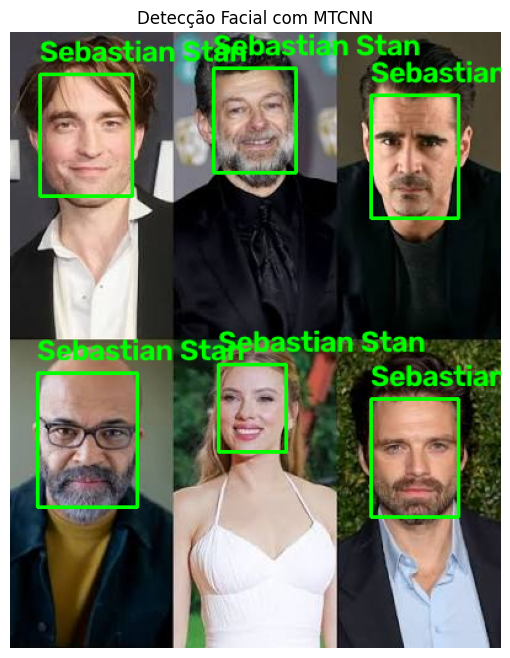

In [7]:
# 1. Instalando as bibliotecas
!pip install mtcnn lz4 -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import shutil
from mtcnn import MTCNN
from google.colab import files

print("1. Criando a estrutura de pastas e o dataset...")
base_dir = 'dataset_faces'
classes = ['Robert Pattinson', 'Andy Serkis', 'Colin Farrell', 'Jeffrey Wright', 'Scarlett Johansson', 'Sebastian Stan']

# Limpeza: Apaga a pasta inteira se ela já existir de testes anteriores
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Criando as pastas limpas
for c in classes:
    os.makedirs(os.path.join(base_dir, 'treino', c), exist_ok=True)

# Gerando dados temporários (ruído) apenas para o modelo compilar
for c in classes:
    for i in range(10):
        img_temp = np.random.randint(0, 255, (128, 128, 3), dtype=np.uint8)
        cv2.imwrite(os.path.join(base_dir, 'treino', c, f'temp_{i}.jpg'), img_temp)

print("2. Carregando os dados no TensorFlow...")
BATCH_SIZE = 8
IMG_SIZE = (128, 128)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'treino'),
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("3. Construindo a Rede Neural de Classificação (CNN)...")
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Iniciando o treinamento da rede de classificação...")
model.fit(train_dataset, epochs=6)

print("4. Preparando a Rede de Detecção (MTCNN)...")
detector = MTCNN()

print("5. Faça o upload de uma imagem com as pessoas para testar (ex: foto em grupo):")
uploaded = files.upload()

# Pegando o nome do arquivo enviado
nome_arquivo = next(iter(uploaded))

# Lendo a imagem da memória para o formato OpenCV
img_array = np.frombuffer(uploaded[nome_arquivo], np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Executando Detecção e Reconhecimento...")
# Detectando os rostos diretamente com a rede MTCNN
faces = detector.detect_faces(img_rgb)

for face in faces:
    x, y, w, h = face['box']

    # Prevenindo coordenadas negativas
    x, y = max(0, x), max(0, y)

    rosto = img_rgb[y:y+h, x:x+w]

    if rosto.shape[0] == 0 or rosto.shape[1] == 0:
        continue

    rosto_resized = cv2.resize(rosto, IMG_SIZE)
    rosto_array = np.expand_dims(rosto_resized, axis=0)

    # Passando a face na nossa rede de Classificação
    pred = model.predict(rosto_array, verbose=0)
    idx_classe = np.argmax(pred)
    nome = classes[idx_classe]

    # Desenhando a caixa (Bounding Box) e o nome
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img_rgb, nome, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# Exibindo o resultado final
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Detecção Facial com MTCNN')
plt.show()